# Recommendation Scoring Model

## Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

## Loading Data

In [8]:
df = pd.read_csv('Reviews.csv',on_bad_lines='skip', engine='python')

## Early Feature Engineering & undersampling
I have seen further in the code that this feature is needed so it needs to be done before undersampling for accurate results

for undersampling here the data before undersampling it had imbalance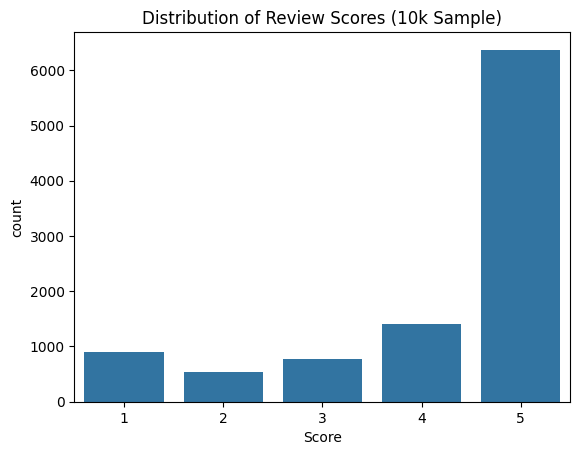

### Sentiment Analysis

In [9]:
from textblob import TextBlob

# Polarity: -1 is negative, 1 is positive
def get_sentiment(text):
    return TextBlob(str(text)).sentiment.polarity

# Subjectivity: 0 is objective, 1 is subjective
def get_subjectivity(text):
    return TextBlob(str(text)).sentiment.subjectivity

df['Polarity'] = df['Text'].apply(get_sentiment)
df['Subjectivity'] = df['Text'].apply(get_subjectivity)

In [10]:
# Create the "Interaction Propensity" Score (Target) based on raw scores
# Will use Score to create target - simple and intuitive
df['Will_Interact'] = (df['Score'] >= 4).astype(int)

print("Target variable created based on ratings >= 4")
print(df[['ProductId', 'Score', 'Will_Interact']].head())


Target variable created based on ratings >= 4
    ProductId  Score  Will_Interact
0  B001E4KFG0      5              1
1  B00813GRG4      1              0
2  B000LQOCH0      4              1
3  B000UA0QIQ      2              0
4  B006K2ZZ7K      5              1


In [11]:
print(df['Score'].value_counts())

Score
5    44546
4    10343
1     6791
3     5674
2     3967
Name: count, dtype: int64


The Score column shows imbalance, we can use undersampling to get better score representation

In [12]:
# using 25000 as sthe class 2 has the least rows of 29769
df = df.groupby('Score').sample(n=3000, random_state=42).reset_index(drop=True)
print(df['Score'].value_counts())

Score
1    3000
2    3000
3    3000
4    3000
5    3000
Name: count, dtype: int64


Text(0.5, 1.0, 'Distribution of Review Scores (25k Sample)')

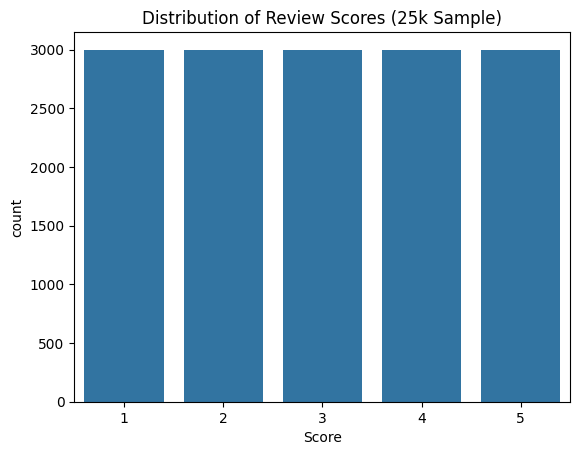

In [13]:
sns.countplot(x='Score', data=df)
plt.title('Distribution of Review Scores (25k Sample)')

In [14]:
print(df['Will_Interact'].value_counts())

Will_Interact
0    9000
1    6000
Name: count, dtype: int64


In [15]:
# Undersample to 45,000 samples for each 'Will_Interact' class
df = df.groupby('Will_Interact').sample(n=6000, random_state=42).reset_index(drop=True)

# Print the value counts to verify the balance
print(df['Will_Interact'].value_counts())

Will_Interact
0    6000
1    6000
Name: count, dtype: int64


Text(0.5, 1.0, 'Distribution of Interaction chance')

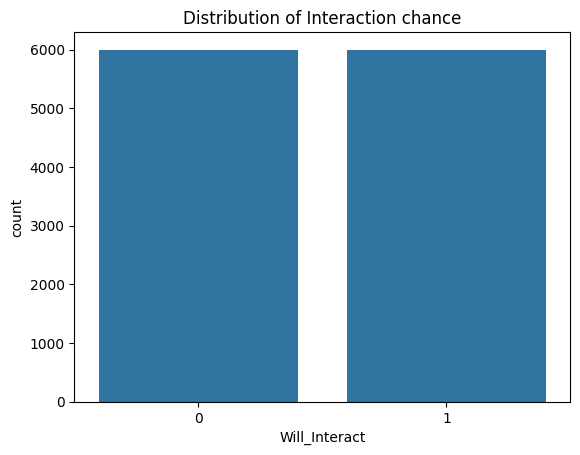

In [16]:
sns.countplot(x='Will_Interact', data=df)
plt.title('Distribution of Interaction chance')

## Exploratory Data Analysis

In [17]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Polarity,Subjectivity,Will_Interact
0,31631,B0006VB3TA,A2PFR44TT6VHX8,"Thomas Hiday ""HIDAYROZE""",1,1,3,1325030400,EVERLASTING TREAT,"MY DOGS LOVED IT FOR THE TASTE, I THINK. AND I...",0.202813,0.690521,0
1,27835,B000SP1CWW,A2M687HYOW9JFW,dream factory,1,1,1,1280534400,Garbage!,My puppy Paw Paw hates this stuff.And I hate i...,-0.070000,0.440000,0
2,45323,B0005XN9HI,A1W8OY1CH31XDP,Coyote Osborne,3,7,1,1309305600,Overhyped and inferior,"The tomato flavor is inferior, the taste is ex...",-0.097500,0.514048,0
3,68813,B0002NVLKS,A1VDR5M6GJ1A2K,"rc13 ""rc13""",4,4,2,1272844800,Disappointing!,I thought this was a fair price for these mush...,-0.101111,0.630000,0
4,23166,B004ZIER34,A1SI2993YY7C61,tomahagne,1,1,3,1314316800,"In the end, it's the taste that matters",I don't really fit the presumed target audienc...,0.274484,0.513016,0


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Id                      12000 non-null  int64  
 1   ProductId               12000 non-null  object 
 2   UserId                  12000 non-null  object 
 3   ProfileName             11999 non-null  object 
 4   HelpfulnessNumerator    12000 non-null  int64  
 5   HelpfulnessDenominator  12000 non-null  int64  
 6   Score                   12000 non-null  int64  
 7   Time                    12000 non-null  int64  
 8   Summary                 11999 non-null  object 
 9   Text                    12000 non-null  object 
 10  Polarity                12000 non-null  float64
 11  Subjectivity            12000 non-null  float64
 12  Will_Interact           12000 non-null  int64  
dtypes: float64(2), int64(6), object(5)
memory usage: 1.2+ MB


In [19]:
df.describe()

,Id,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Polarity,Subjectivity,Will_Interact
count,12000.000000,12000.000000,12000.000000,12000.000000,1.200000e+04,12000.000000,12000.000000,12000.000000
mean,35887.710667,1.590667,2.363667,3.248500,1.295997e+09,0.174469,0.534476,0.500000
std,20677.605629,4.388874,5.384561,1.422175,4.727964e+07,0.223847,0.148171,0.500021
min,4.000000,0.000000,0.000000,1.000000,1.067040e+09,-1.000000,0.000000,0.000000
25%,18138.750000,0.000000,0.000000,2.000000,1.271635e+09,0.047297,0.453333,0.000000
50%,36162.000000,0.000000,1.000000,3.500000,1.310515e+09,0.168787,0.533333,0.500000
75%,53931.500000,2.000000,3.000000,4.250000,1.332374e+09,0.300000,0.620833,1.000000
max,71304.000000,180.000000,188.000000,5.000000,1.351210e+09,1.000000,1.000000,1.000000


This shows that the data still kept its statistics and didn't get affected by the undersampling, except for the score it changed to a mean of 3 meaning its now balanced!

<Axes: >

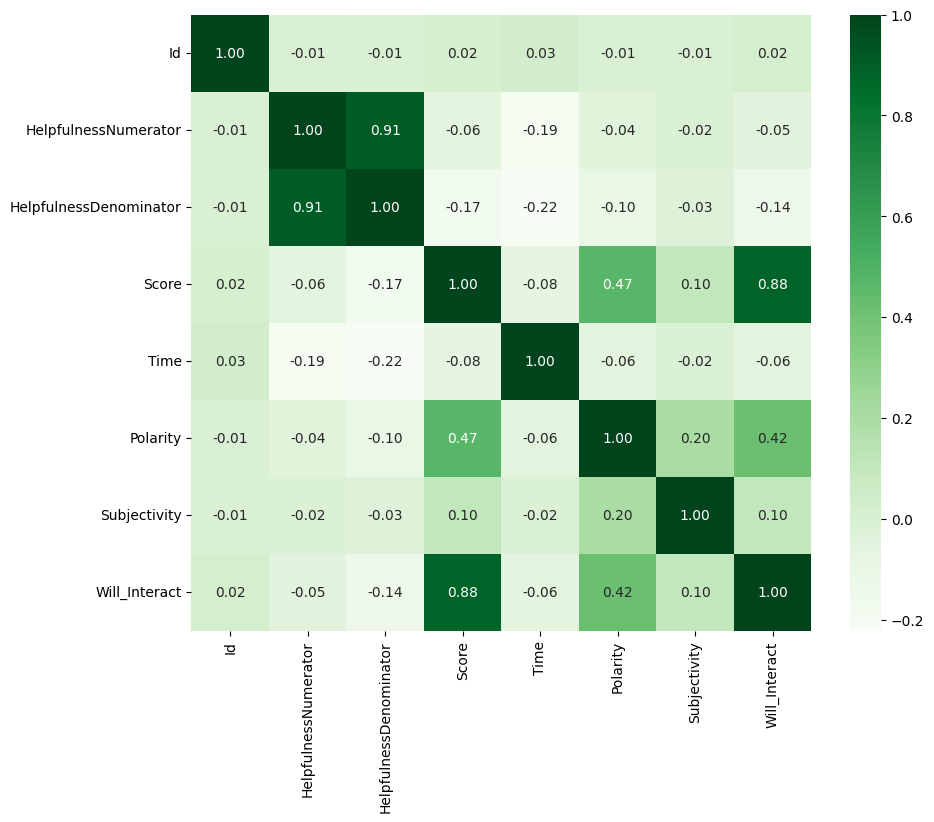

In [20]:
plt.figure(figsize=(10,8))
numeric_cols = df.select_dtypes(include=[np.number])
corr = numeric_cols.corr()

sns.heatmap(corr, annot=True, cmap='Greens', fmt='.2f')

In [21]:
df.isnull().sum()

,0
Id,0
ProductId,0
UserId,0
ProfileName,1
HelpfulnessNumerator,0
HelpfulnessDenominator,0
Score,0
Time,0
Summary,1
Text,0


In [22]:
df = df.dropna()

In [23]:
df.isnull().sum()

,0
Id,0
ProductId,0
UserId,0
ProfileName,0
HelpfulnessNumerator,0
HelpfulnessDenominator,0
Score,0
Time,0
Summary,0
Text,0


In [24]:
df.duplicated().sum()

np.int64(0)

## Feature Engineering

In [25]:
from sklearn.preprocessing import MinMaxScaler

product_stats = df.groupby('ProductId').agg({
    'Score': 'mean',
    'UserId': 'count',
    'Polarity': 'mean',
    'Subjectivity': 'mean'
}).rename(columns={
    'Score': 'Avg_Product_Rating',
    'UserId': 'Total_Purchases',
    'Polarity': 'Product_Vibe_Score',
    'Subjectivity': 'Product_Subjectivity_Avg'
})

df = df.merge(product_stats, on='ProductId', how='left')
print('Product-level features calculated from undersampled data (NO LEAKAGE)')
print('New columns:', df.columns.tolist())


Product-level features calculated from undersampled data (NO LEAKAGE)
New columns: ['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text', 'Polarity', 'Subjectivity', 'Will_Interact', 'Avg_Product_Rating', 'Total_Purchases', 'Product_Vibe_Score', 'Product_Subjectivity_Avg']


In [26]:


df['Date'] = pd.to_datetime(df['Time'], unit='s')
df['Year'] = df['Date'].dt.year

df['Helpfulness_Ratio'] = df['HelpfulnessNumerator'] / df['HelpfulnessDenominator']
df['Helpfulness_Ratio'] = df['Helpfulness_Ratio'].replace([np.inf, -np.inf], 0).fillna(0)

df['Review_Length'] = df['Text'].apply(lambda x: len(str(x).split()))


## More EDA!

/tmp/ipykernel_7893/1173525359.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Score', y='Helpfulness_Ratio', data=df, palette='Set2')


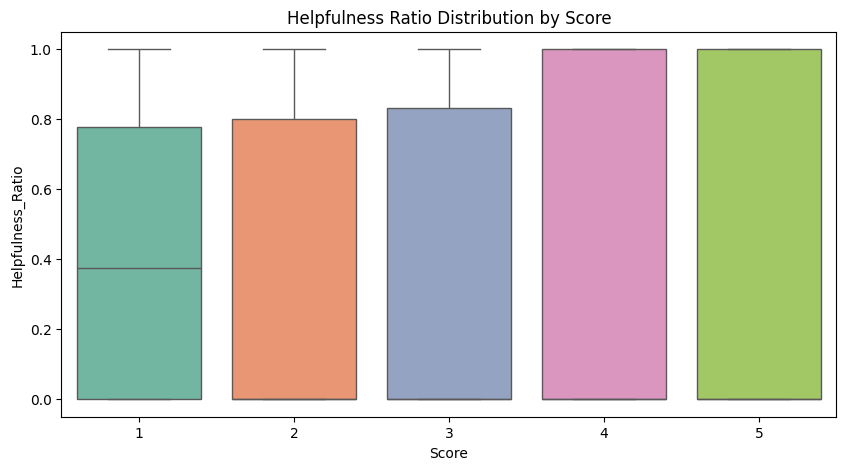

In [27]:

plt.figure(figsize=(10, 5))
sns.boxplot(x='Score', y='Helpfulness_Ratio', data=df, palette='Set2')
plt.title('Helpfulness Ratio Distribution by Score')
plt.show()


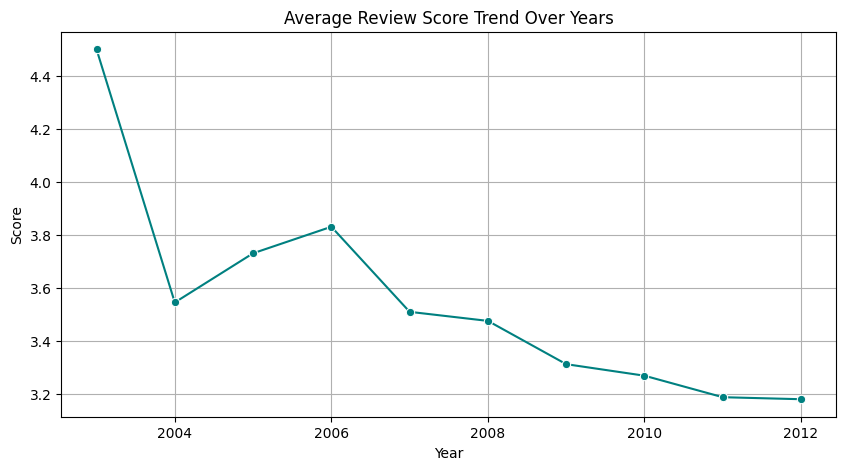

In [28]:

plt.figure(figsize=(10, 5))
yearly_avg = df.groupby('Year')['Score'].mean().reset_index()
sns.lineplot(x='Year', y='Score', data=yearly_avg, marker='o', color='teal')
plt.title('Average Review Score Trend Over Years')
plt.grid(True)
plt.show()


/tmp/ipykernel_7893/2126808695.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Score', y='Review_Length', data=df, palette='mako')


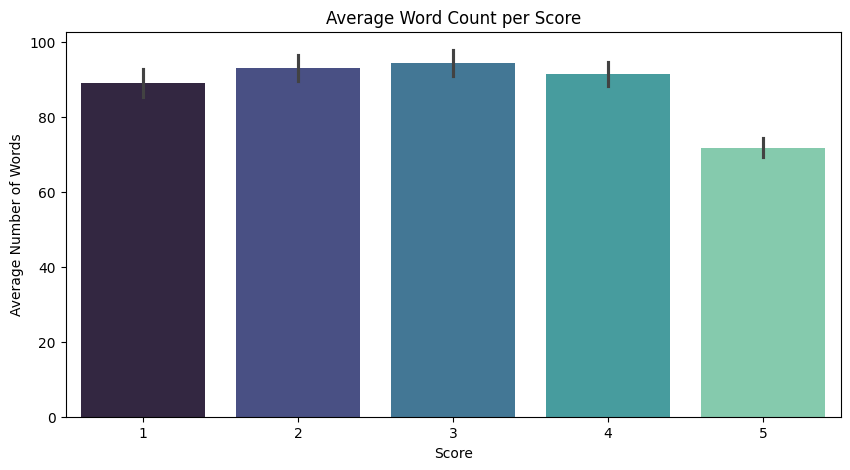

In [29]:

plt.figure(figsize=(10, 5))
sns.barplot(x='Score', y='Review_Length', data=df, palette='mako')
plt.title('Average Word Count per Score')
plt.ylabel('Average Number of Words')
plt.show()

/tmp/ipykernel_7893/243751389.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x='Score', y='Polarity', data=df, palette='RdYlGn')


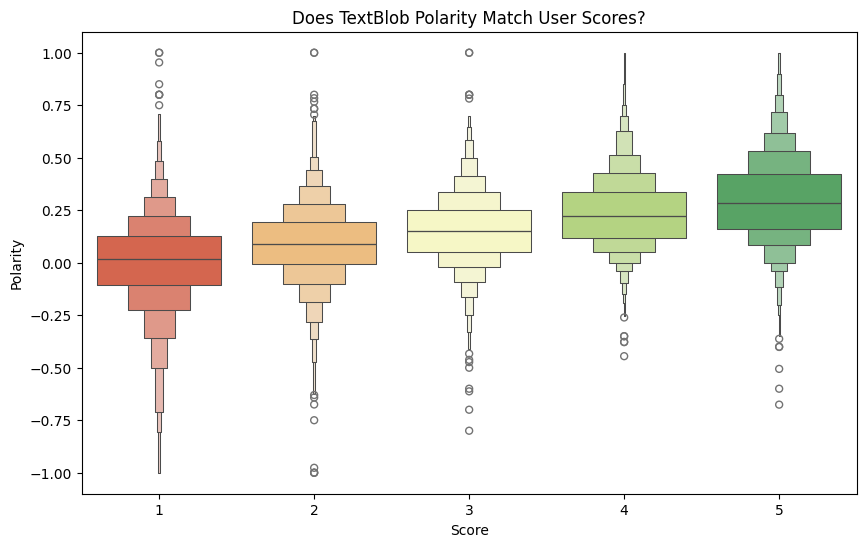

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxenplot(x='Score', y='Polarity', data=df, palette='RdYlGn')
plt.title('Does TextBlob Polarity Match User Scores?')
plt.show()

## Model Building, Training, and Evaluation

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Selecting features
features = [
    'Product_Subjectivity_Avg',
    'Year',
    'Product_Vibe_Score',
    'Helpfulness_Ratio',
    'Avg_Product_Rating',
    'Total_Purchases',
    'Review_Length'
]


X = df[features].values
y = df['Will_Interact'].values

# Splitting data
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.176, random_state=42, stratify=y_train_full
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Building the model
def build_model(input_shape):
    model = models.Sequential([
        layers.Input(shape=(input_shape,)),

        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        layers.Dense(32, activation='relu'),

        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model

model = build_model(X_train.shape[1])

# Training
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# Evaluation
print("\n" + "="*30)
print("FINAL MODEL EVALUATION")
print("="*30)

# Predictions
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)


Epoch 1/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6953 - auc: 0.7743 - loss: 0.5647 - val_accuracy: 0.7304 - val_auc: 0.8192 - val_loss: 0.5704
Epoch 2/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7256 - auc: 0.8087 - loss: 0.5226 - val_accuracy: 0.7315 - val_auc: 0.8294 - val_loss: 0.5196
Epoch 3/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7299 - auc: 0.8115 - loss: 0.5209 - val_accuracy: 0.7471 - val_auc: 0.8319 - val_loss: 0.4979
Epoch 4/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7301 - auc: 0.8169 - loss: 0.5108 - val_accuracy: 0.7565 - val_auc: 0.8371 - val_loss: 0.4870
Epoch 5/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7390 - auc: 0.8226 - loss: 0.5062 - val_accuracy: 0.7549 - val_auc: 0.8433 - val_loss: 0.4828
Epoch 6/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7441 - auc: 0.8284 - loss: 0.4993 - val_accuracy: 0.7627 - val_auc: 0.8480 - val_loss: 0.4746
Epoch 7/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 

## Rresults Visualization

                precision    recall  f1-score   support

Won't Interact       0.77      0.77      0.77       900
 Will Interact       0.77      0.77      0.77       900

      accuracy                           0.77      1800
     macro avg       0.77      0.77      0.77      1800
  weighted avg       0.77      0.77      0.77      1800



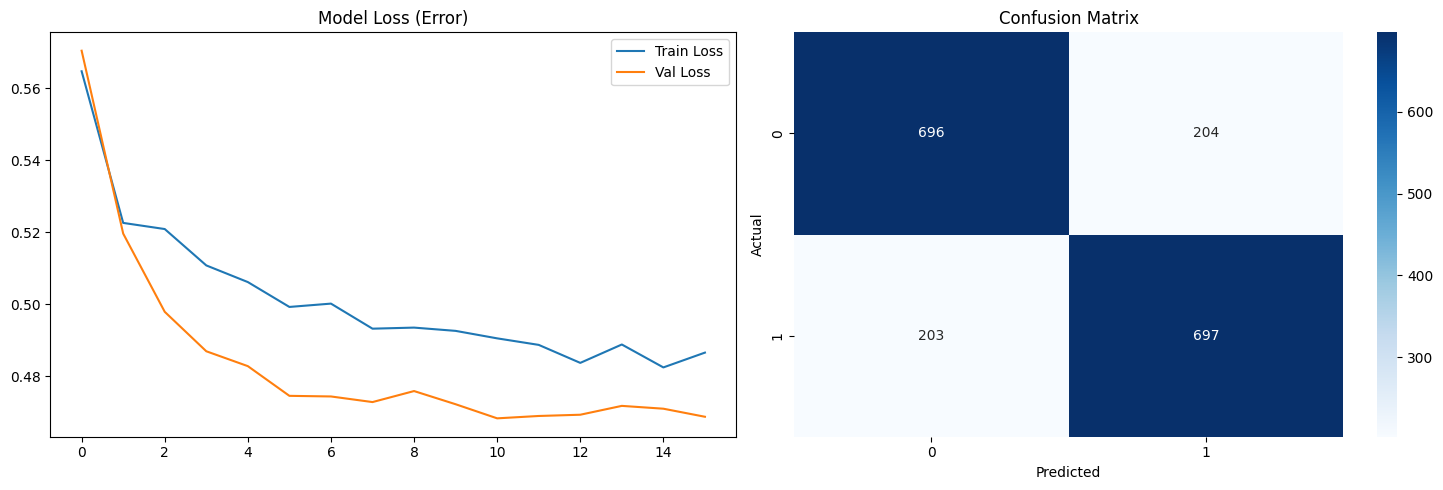

Final AUC-ROC Score: 0.8540


In [33]:

# Classification Report
print(classification_report(y_test, y_pred, target_names=['Won\'t Interact', 'Will Interact']))

# Visualizing Results
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Loss Curves
ax[0].plot(history.history['loss'], label='Train Loss')
ax[0].plot(history.history['val_loss'], label='Val Loss')
ax[0].set_title('Model Loss (Error)')
ax[0].legend()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[1])
ax[1].set_title('Confusion Matrix')
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# AUC-ROC Score
auc_score = roc_auc_score(y_test, y_pred_prob)
print(f"Final AUC-ROC Score: {auc_score:.4f}")